In [30]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

engine = create_engine("sqlite:///../data/full_results2.db")
df_raw = pd.read_sql("SELECT * FROM names", con=engine)

# ── Cleaning (matches notebooks 07 and 08) ───────────────────────────────────
# Remove multi-word names, digits, noise punctuation.
# Hyphens and apostrophes are kept (O'Brien, Mary-Jane).
NOISE = r"[\s*._0-9@#$%^&+=|<>{}\[\]\\;:,!?~/'\"]"

mask_clean = ~df_raw["name"].str.contains(NOISE, regex=True, na=True)
df = df_raw[mask_clean].copy()

removed = len(df_raw) - len(df)
print(f"Full dataset:    {len(df_raw):,}")
print(f"Removed (noise): {removed:,}  ({100*removed/len(df_raw):.1f}%)")
print(f"Cleaned dataset: {len(df):,}  ({100*len(df)/len(df_raw):.1f}% retained)")
print(f"Unique names:    {df['name'].nunique():,}")
print(f"Unique countries:{df['top_country'].nunique():,}")
print(f"Langdetect langs:{df['langdetect_lang'].nunique():,}")


Full dataset:    727,352
Removed (noise): 156,159  (21.5%)
Cleaned dataset: 571,193  (78.5% retained)
Unique names:    571,193
Unique countries:105
Langdetect langs:55


In [31]:
df_latin = pd.read_sql(f"SELECT * FROM names WHERE name = name_latin", con=engine)

if "top_country" in df_latin.columns:
    unique_latin_countries = df_latin["top_country"].dropna().unique().tolist()
else:
    unique_latin_countries = []

print("Countries with latin names", unique_latin_countries)

Countries with latin names ['United States', 'Panama', 'Ethiopia', 'Bangladesh', 'Costa Rica', 'Hungary', 'Slovenia', 'Georgia', 'Portugal', 'Azerbaijan', 'Saudi Arabia', 'Türkiye', 'Lebanon', 'Egypt', 'Cyprus', 'Indonesia', 'Macao', 'Denmark', 'Spain', 'Malaysia', 'Nigeria', 'Maldives', 'India', 'Moldova, Republic of', 'Peru', 'Afghanistan', 'Colombia', 'Lithuania', 'Mexico', 'Poland', 'Puerto Rico', 'United Arab Emirates', 'Croatia', 'Brazil', 'Ecuador', 'Fiji', 'Botswana', 'Serbia', 'Iceland', 'Honduras', 'Ireland', 'Morocco', 'Iran, Islamic Republic of', 'Hong Kong', 'Namibia', 'Malta', 'Italy', 'Jamaica', 'Uruguay', 'Ghana', 'Djibouti', 'Kuwait', 'Canada', 'Taiwan, Province of China', 'Bulgaria', 'Estonia', 'Argentina', 'Singapore', 'Brunei Darussalam', 'France', 'United Kingdom', 'South Africa', 'Germany', 'Burkina Faso', 'Finland', 'Luxembourg', 'Bahrain', 'Tunisia', 'Netherlands', 'Algeria', 'Norway', 'Palestine, State of', 'Syrian Arab Republic', 'Oman', 'Sudan', 'Belgium', 'C

In [32]:
# Counting entries with strong_top_country
strong_count = df["strong_top_country"].sum()
print(f"Names with strong top country: {strong_count:,}")
print(f"Percentage of cleaned data:    {100 * strong_count / len(df):.1f}%")

# Counting entries with langdetect language matching official languages of top_country
country_language_match = df["country_lang_comp"].sum()
print(f"Names with langdetect language matching an official language of top_country: {country_language_match:,}")
print(f"Percentage of cleaned data:    {100 * country_language_match / len(df):.1f}%")

Names with strong top country: 250,976
Percentage of cleaned data:    43.9%
Names with langdetect language matching an official language of top_country: 98,430
Percentage of cleaned data:    17.2%


In [33]:
# Get script counts and convert to DataFrame
script_counts = df["name_script"].value_counts().reset_index()
script_counts.columns = ["script", "count"]

script_counts["percentage"] = (script_counts["count"] / len(df)) * 100

# Filter for scripts > 1%
top_scripts = script_counts[script_counts["percentage"] > 1].copy()

print("Scripts making up > 1% of the dataset:")
print(top_scripts)

Scripts making up > 1% of the dataset:
     script   count  percentage
0     Latin  463575   81.159083
1    Arabic   32255    5.646953
2  Cyrillic   26637    4.663397
3       CJK   20290    3.552214
4    Hangul   12324    2.157589


In [34]:
# Country counts of strong (>=0.7) predictions
df_strong = df[df["strong_top_country"] == True]

country_counts = df_strong["top_country"].value_counts().reset_index()
country_counts.columns = ["country", "count"]
country_counts["percentage"] = (country_counts["count"] / len(df_strong)) * 100
country_counts["cumulative_pct"] = country_counts["percentage"].cumsum()

# Display the top 10 for a quick look
print(f"Total strong matches: {len(df_strong):,}")
print("-" * 30)
print(country_counts.head())

# Filter for countries making up the top 95% of confident data
top_95_countries = country_counts[country_counts["cumulative_pct"] <= 95.5]
print(f"\nNumber of countries covering 95% of strong matches: {len(top_95_countries)}")

Total strong matches: 250,976
------------------------------
              country  count  percentage  cumulative_pct
0        South Africa  11929    4.753044        4.753044
1             Nigeria  11148    4.441859        9.194903
2  Korea, Republic of  11085    4.416757       13.611660
3  Russian Federation  10618    4.230683       17.842343
4          Kazakhstan  10075    4.014328       21.856672

Number of countries covering 95% of strong matches: 71


In [35]:
# 1. Define the labels for Britain/UK - Ireland included as ethnicolr does not have a separate race group for Irish
uk_variants = ['United Kingdom', 'Ireland']
found_uk_labels = [c for c in df['top_country'].unique() if c in uk_variants]

# 2. Filter and count for Country
uk_country_count = df[df['top_country'].isin(found_uk_labels)].shape[0]

# 3. Filter and count for 'British' as the last item in ethnicolr_race
# We split by comma and grab the last index [-1]
british_eth_count = df['ethnicolr_race'].str.split(',').str[-1].eq('British').sum()

print(f"Names associated with UK/Britain (top_country): {uk_country_count:,}, {uk_country_count/len(df) * 100}")
print(f"Labels found in data: {found_uk_labels}")
print("-" * 40)
print(f"Names classified as 'British' (ethnicolr_race): {british_eth_count:,}, {british_eth_count/len(df) * 100}")

Names associated with UK/Britain (top_country): 5,745, 1.0057896367777617
Labels found in data: ['United Kingdom', 'Ireland']
----------------------------------------
Names classified as 'British' (ethnicolr_race): 97,768, 17.11645625909281


In [36]:
# 1. Define a confidence threshold (e.g., 0.7 to match strong_top_country)
threshold = 0.7

# 2. Create the two groups
df_high = df[df['langdetect_prob'] >= threshold]
df_low = df[df['langdetect_prob'] < threshold]

# 3. Get the distribution for both
high_dist = df_high['langdetect_lang_name'].value_counts(normalize=True).head(10) * 100
low_dist = df_low['langdetect_lang_name'].value_counts(normalize=True).head(10) * 100

print(f"Total Low Confidence rows (< {threshold}): {len(df_low):,}")
print("-" * 30)
print("Top 10 Languages in HIGH Confidence rows:")
print(high_dist)
print("\nTop 10 Languages in LOW Confidence rows:")
print(low_dist)

Total Low Confidence rows (< 0.7): 58,753
------------------------------
Top 10 Languages in HIGH Confidence rows:
langdetect_lang_name
Indonesian                 6.416330
Swahili (macrolanguage)    5.799983
Somali                     5.586610
Korean                     5.448290
German                     5.238257
English                    4.909945
Tagalog                    4.786165
Arabic                     3.712618
Turkish                    3.397077
Italian                    3.355620
Name: proportion, dtype: float64

Top 10 Languages in LOW Confidence rows:
langdetect_lang_name
Indonesian                 7.209845
Swahili (macrolanguage)    6.666894
English                    6.236277
German                     5.953739
Somali                     5.421000
Tagalog                    5.182714
Finnish                    4.142767
Estonian                   4.129151
Welsh                      3.788743
Turkish                    3.785339
Name: proportion, dtype: float64


In [37]:
# Create a comparison dataframe
bias_df = pd.DataFrame({
    'high_pct': high_dist,
    'low_pct': low_dist
}).fillna(0)

# Calculate how much more likely a language is to appear when confidence is LOW (<0.7 aka not HIGH)
# A ratio > 1.0 means it's a "Sink" language (it grows when the model is confused)
bias_df['bias_ratio'] = bias_df['low_pct'] / bias_df['high_pct']

# Sort by the most biased (the "Sinks")
print("Languages that 'absorb' low-confidence names (Highest Bias Ratio):")
print(bias_df[bias_df['high_pct'] > 0].sort_values('bias_ratio', ascending=False))

Languages that 'absorb' low-confidence names (Highest Bias Ratio):
                         high_pct   low_pct  bias_ratio
langdetect_lang_name                                   
English                  4.909945  6.236277    1.270132
Swahili (macrolanguage)  5.799983  6.666894    1.149468
German                   5.238257  5.953739    1.136588
Indonesian               6.416330  7.209845    1.123671
Turkish                  3.397077  3.785339    1.114293
Tagalog                  4.786165  5.182714    1.082853
Somali                   5.586610  5.421000    0.970356
Arabic                   3.712618  0.000000    0.000000
Italian                  3.355620  0.000000    0.000000
Korean                   5.448290  0.000000    0.000000


In [38]:
# Country counts
country_counts = df["top_country"].value_counts().reset_index()
country_counts.columns = ["country", "count"]
country_counts["percentage"] = (country_counts["count"] / len(df)) * 100
# country_counts["cumulative_pct"] = country_counts["percentage"].cumsum()

# Display the top 10 for a quick look
print(country_counts.head(10))

# Filter for countries making up the top 95% of confident data
# top_95_countries = country_counts[country_counts["cumulative_pct"] <= 95.5]
# print(f"\nNumber of countries covering 95% of dataset: {len(top_95_countries)}")

              country  count  percentage
0        Saudi Arabia  25196    4.411118
1       United States  25106    4.395362
2        South Africa  20677    3.619967
3            Malaysia  19911    3.485862
4  Russian Federation  16633    2.911975
5               Italy  15697    2.748108
6               Egypt  15459    2.706441
7             Nigeria  15298    2.678254
8              Brazil  13753    2.407768
9  Korea, Republic of  13751    2.407417


In [39]:
# Focus on typically English-speaking countries
anglo_list = ["United States", "United Kingdom", "Canada", "Australia", "New Zealand", "Ireland"]
english_speaking_df = country_counts[country_counts["country"].isin(anglo_list)].copy()

total_english_count = english_speaking_df["count"].sum()
total_english_pct = english_speaking_df["percentage"].sum()

print("\n--- Typically English Speaking Countries ---")
print(english_speaking_df[["country", "count", "percentage"]])
print("-" * 30)
print(f"Total Anglo-Socio-Group: {total_english_count:,} ({total_english_pct:.2f}%)")


--- Typically English Speaking Countries ---
           country  count  percentage
1    United States  25106    4.395362
51  United Kingdom   4063    0.711318
76         Ireland   1682    0.294471
87          Canada   1331    0.233021
------------------------------
Total Anglo-Socio-Group: 32,182 (5.63%)


In [40]:
# Define the base Condition B tools
PRIMARY_B = [
    ('Hunspell', 'hunspell_latin_known'),
    ('SymSpell', 'symspell_latin_known'),
    ('LT-auto', 'lt_auto_latin_known')
]

# Define the Extended set adding the 'Orig' condition
EXTENDED = PRIMARY_B + [('LT-auto (Orig)', 'lt_auto_orig_known')]

def script_breakdown(frame, min_n=500):
    rows = []
    for cat, grp in frame.groupby('name_script', observed=True):
        if len(grp) < min_n:
            continue
            
        row = {'Category': cat, 'n': len(grp)}
        for lbl, col in EXTENDED:
            # grp[col] contains 1 for known, 0 for flagged
            known_pct = grp[col].mean() * 100
            row[f'{lbl} flagged%'] = round(100 - known_pct, 1)
            row[f'{lbl} known%']   = round(known_pct, 1)
        rows.append(row)
    
    if not rows:
        return pd.DataFrame()

    sort_col = f"{EXTENDED[0][0]} flagged%" 
    return (pd.DataFrame(rows)
            .sort_values(sort_col, ascending=False)
            .reset_index(drop=True))

script_brk = script_breakdown(df)
display(script_brk.set_index('Category'))

,n,Hunspell flagged%,Hunspell known%,SymSpell flagged%,SymSpell known%,LT-auto flagged%,LT-auto known%,LT-auto (Orig) flagged%,LT-auto (Orig) known%
Category,,,,,,,,,
CJK,20290,100.0,0.0,99.0,1.0,37.8,62.2,100.0,0.0
Hangul,12324,100.0,0.0,99.2,0.8,28.9,71.1,100.0,0.0
Hebrew,4209,99.4,0.6,99.6,0.4,91.5,8.5,0.0,100.0
Arabic,32255,98.7,1.3,99.2,0.8,96.3,3.7,35.1,64.9
Ethiopic,685,97.7,2.3,95.8,4.2,88.5,11.5,0.0,100.0
Devanagari,598,95.3,4.7,93.6,6.4,89.5,10.5,0.0,100.0
Bengali,2824,94.7,5.3,93.2,6.8,90.9,9.1,0.0,100.0
Georgian,2098,94.7,5.3,90.6,9.4,87.4,12.6,0.0,100.0
Hiragana,647,94.6,5.4,90.7,9.3,86.9,13.1,100.0,0.0


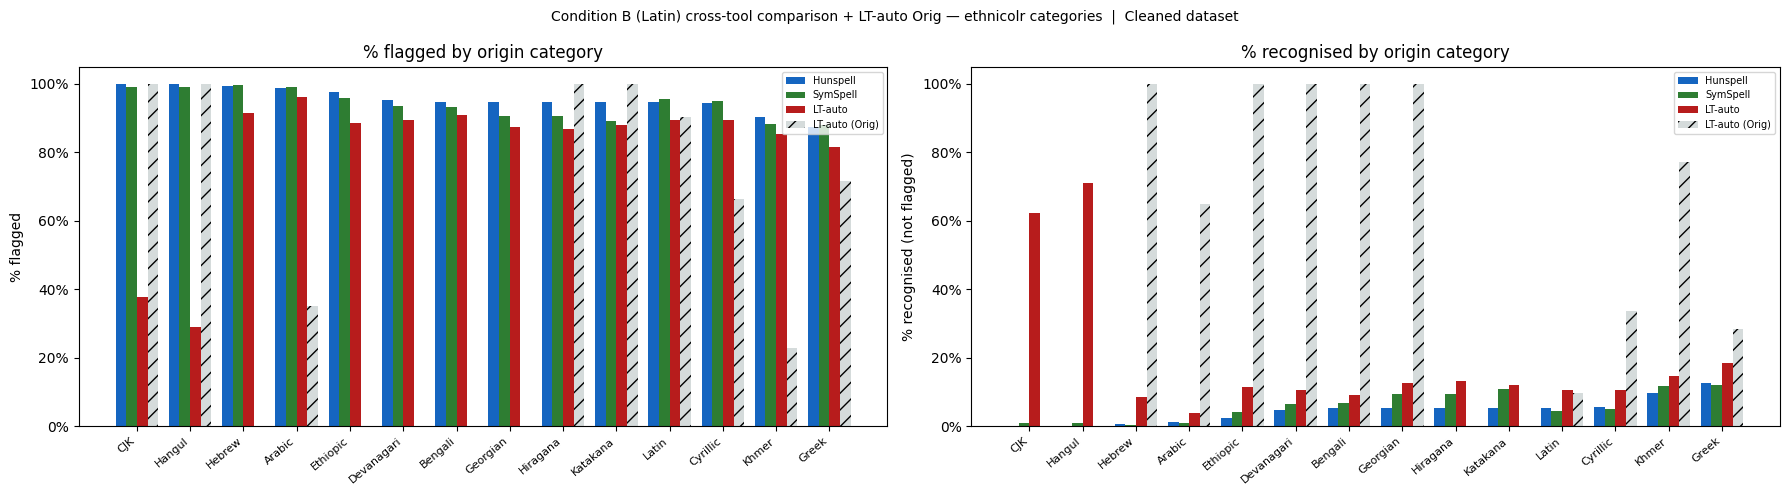

In [41]:
def eth_bar(ax, data, col_suffix='flagged%'):
    cats = data['Category'].tolist()
    x = np.arange(len(cats))
    n_conds = len(EXTENDED)
    w = 0.8 / n_conds
    ETH_BAR_COLOURS = {
    'Hunspell':        '#1565c0',
    'SymSpell':        '#2e7d32',
    'LT-auto':         '#b71c1c',
    'LT-auto (Orig)':  '#D5DBDB',
}
    for i, (lbl, _) in enumerate(EXTENDED):
        # LT-auto (Orig) hatched to distinguish it from the Condition B bars
        hatch = '//' if lbl == 'LT-auto (Orig)' else None
        ax.bar(x + i * w, data[f'{lbl} {col_suffix}'], width=w,
               label=lbl, color=ETH_BAR_COLOURS.get(lbl, '#888888'), hatch=hatch)
    ax.set_xticks(x + w * (n_conds - 1) / 2)
    ax.set_xticklabels(cats, rotation=40, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=7)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5), sharey=False)
eth_bar(ax1, script_brk, col_suffix='flagged%')
eth_bar(ax2, script_brk, col_suffix='known%')
ax1.set_ylabel('% flagged')
ax1.set_title('% flagged by origin category')
ax2.set_ylabel('% recognised (not flagged)')
ax2.set_title('% recognised by origin category')
fig.suptitle(
    'Condition B (Latin) cross-tool comparison + LT-auto Orig — ethnicolr categories  |  Cleaned dataset',
    fontsize=10
)
plt.tight_layout()
plt.show()

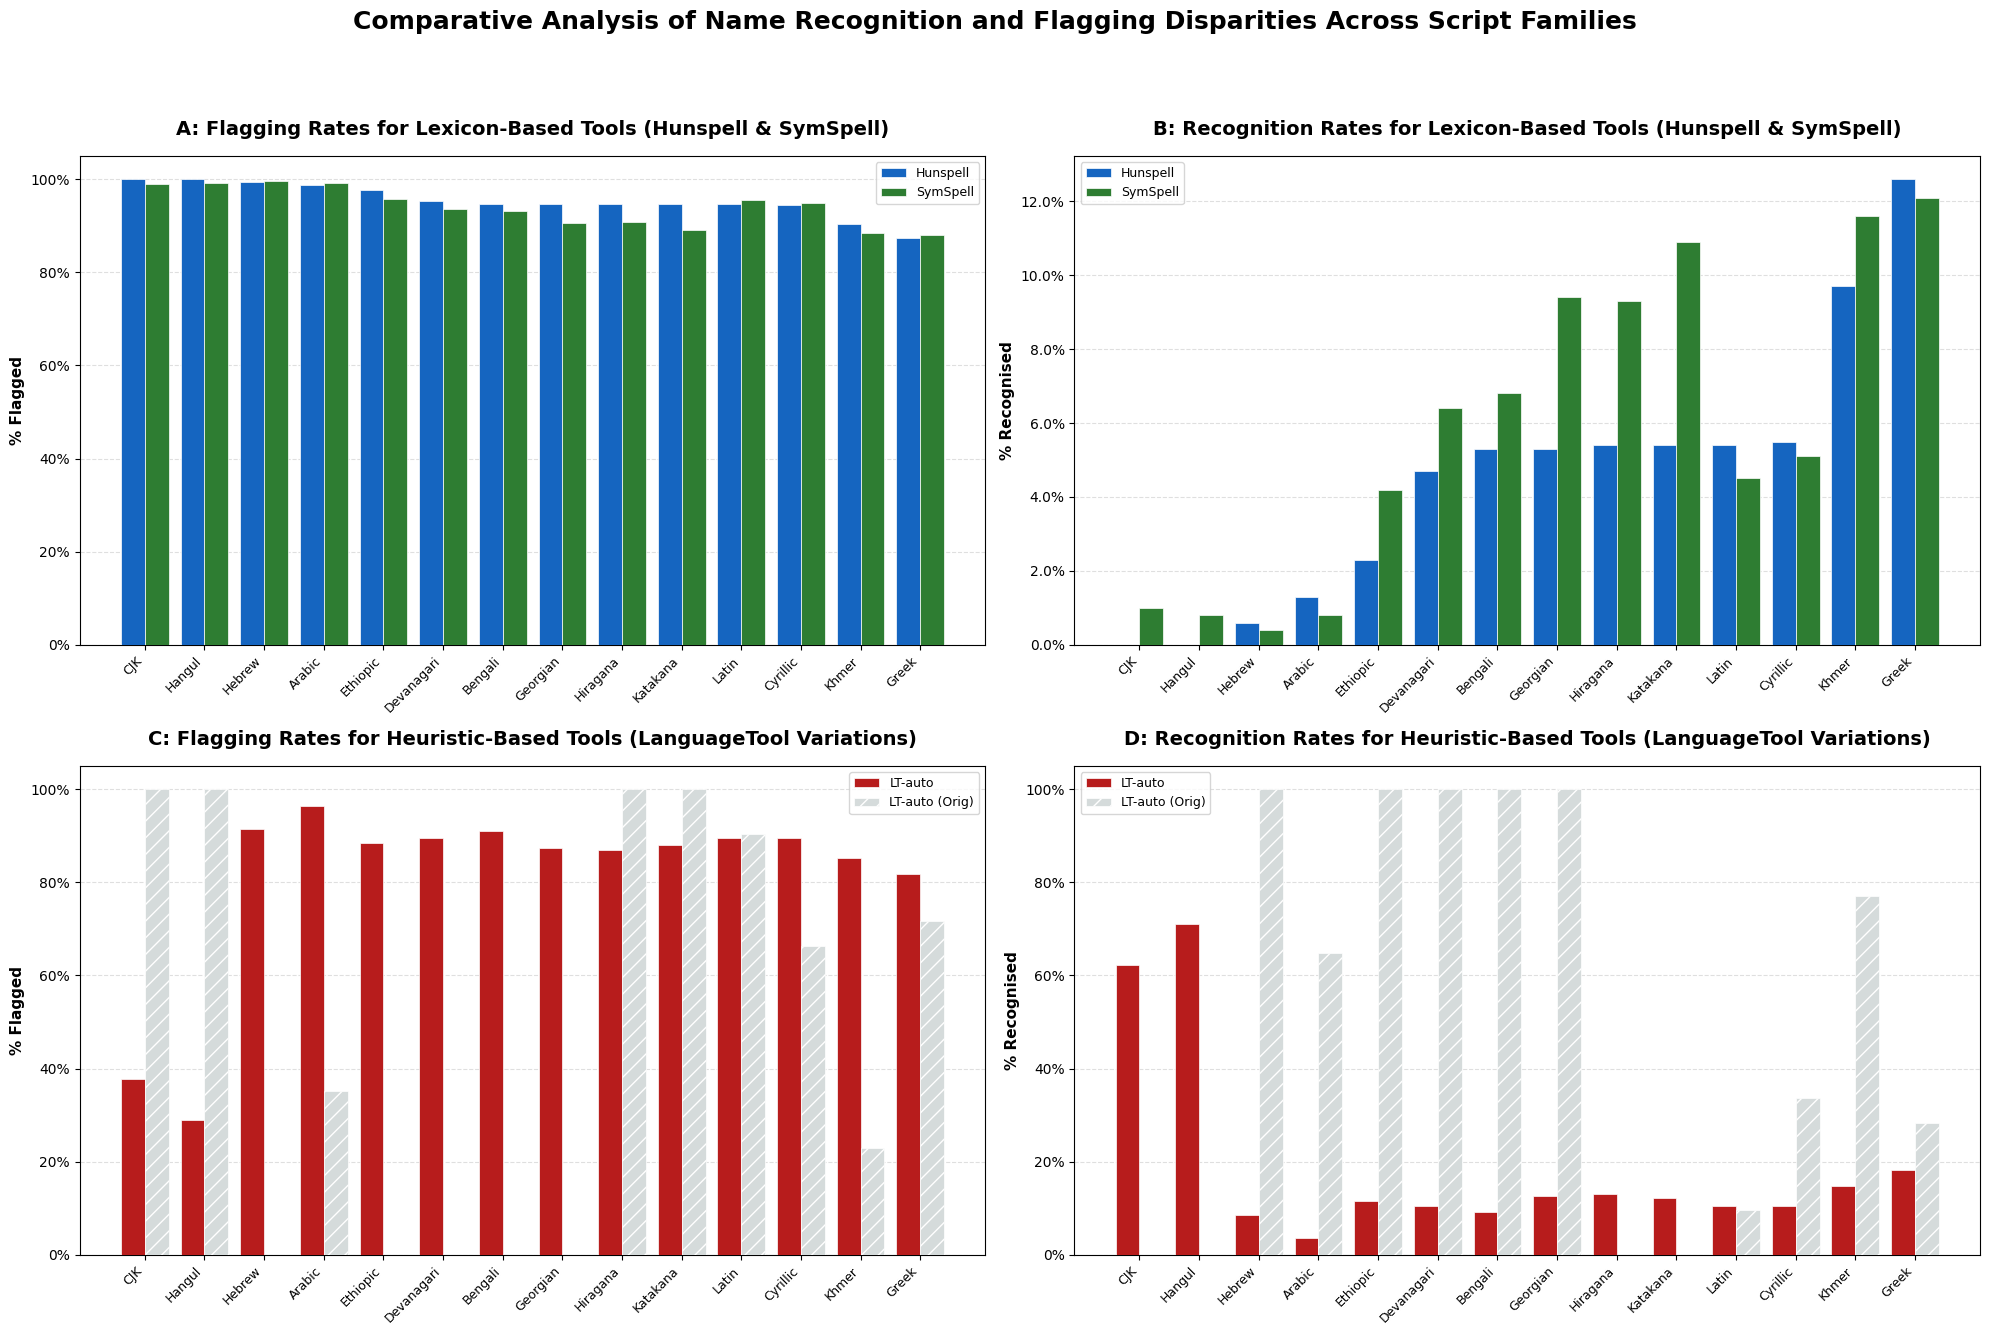

In [42]:
DICT_TOOLS = [
    ('Hunspell', 'hunspell_latin_known'),
    ('SymSpell', 'symspell_latin_known')
]

LT_TOOLS = [
    ('LT-auto', 'lt_auto_latin_known'),
    ('LT-auto (Orig)', 'lt_auto_orig_known')
]

TOOL_COLORS_B = {
    'Hunspell': '#1565c0',
    'SymSpell': '#2e7d32',     
    'LT-auto':  '#b71c1c',      
    'LT-auto (Orig)': '#D5DBDB' 
}

def eth_bar_split(ax, data, tools_to_plot, col_suffix='flagged%', ylabel='Rate (%)', legend_loc='upper right'):
    cats = data['Category'].tolist()
    x = np.arange(len(cats))
    n_conds = len(tools_to_plot)
    w = 0.8 / n_conds
    
    # Iterate through the specific tools passed to this subplot (DICT_TOOLS or LT_TOOLS)
    for i, (lbl, _) in enumerate(tools_to_plot):
        # Apply hatching only to the original script condition
        hatch = '//' if lbl == 'LT-auto (Orig)' else None
        
        # Pull color from our cohesive TOOL_COLORS_B map
        # Fallback to gray if a label is missing
        color = TOOL_COLORS_B.get(lbl, '#D5DBDB')
        
        ax.bar(x + i * w, data[f'{lbl} {col_suffix}'], width=w,
               label=lbl, color=color, hatch=hatch, 
               edgecolor='white', linewidth=0.5, zorder=3)
               
    ax.set_xticks(x + w * (n_conds - 1) / 2)
    ax.set_xticklabels(cats, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=9, loc=legend_loc, frameon=True)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

script_brk = script_breakdown(df)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Row 1: Lexicon-Based Tools
eth_bar_split(axes[0, 0], script_brk, DICT_TOOLS, 
              col_suffix='flagged%', ylabel='% Flagged', legend_loc='upper right')
axes[0, 0].set_title('A: Flagging Rates for Lexicon-Based Tools (Hunspell & SymSpell)', 
                     fontsize=14, fontweight='bold', pad=15)

eth_bar_split(axes[0, 1], script_brk, DICT_TOOLS, 
              col_suffix='known%', ylabel='% Recognised', legend_loc='upper left')
axes[0, 1].set_title('B: Recognition Rates for Lexicon-Based Tools (Hunspell & SymSpell)', 
                     fontsize=14, fontweight='bold', pad=15)

# Row 2: Heuristic-Based Tools
eth_bar_split(axes[1, 0], script_brk, LT_TOOLS, 
              col_suffix='flagged%', ylabel='% Flagged', legend_loc='upper right')
axes[1, 0].set_title('C: Flagging Rates for Heuristic-Based Tools (LanguageTool Variations)', 
                     fontsize=14, fontweight='bold', pad=15)

eth_bar_split(axes[1, 1], script_brk, LT_TOOLS, 
              col_suffix='known%', ylabel='% Recognised', legend_loc='upper left')
axes[1, 1].set_title('D: Recognition Rates for Heuristic-Based Tools (LanguageTool Variations)', 
                     fontsize=14, fontweight='bold', pad=15)

fig.suptitle('Comparative Analysis of Name Recognition and Flagging Disparities Across Script Families', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

## Condition A vs Condition B: Recognition Rates by Script Family (all three tools)

Compares recognition rates under Condition A (original script) and Condition B (Latin transliteration) for all three tools, broken down by script family. Panels are one per tool. Hatched bars = Condition A (original), solid bars = Condition B (Latin).

For Hunspell and SymSpell, Condition A for non-Latin scripts is effectively 0% recognition (tools cannot process non-ASCII), so the A→B gain reflects pure script-compatibility recovery. For LanguageTool, the Condition A bars for several non-Latin scripts show near-100% "recognition" — this is abstention (pass-through), not genuine recognition.

In [43]:
# ── Condition A vs B by script family — all three tools ─────────────────────

ALL_SIX = [
    ('Hunspell',    'hunspell_orig_known',  'hunspell_latin_known'),
    ('SymSpell',    'symspell_orig_known',  'symspell_latin_known'),
    ('LanguageTool','lt_auto_orig_known',   'lt_auto_latin_known'),
]

MIN_N = 500

def ab_script_breakdown(frame, min_n=MIN_N):
    """Return a DataFrame with Cond A and Cond B recognition % per script, per tool."""
    rows = []
    for script, grp in frame.groupby('name_script', observed=True):
        if len(grp) < min_n:
            continue
        row = {'script': script, 'n': len(grp)}
        for tool, col_a, col_b in ALL_SIX:
            row[f'{tool}_A'] = round(grp[col_a].mean() * 100, 2)
            row[f'{tool}_B'] = round(grp[col_b].mean() * 100, 2)
        rows.append(row)
    return pd.DataFrame(rows).sort_values('script').reset_index(drop=True)

ab_brk = ab_script_breakdown(df)

# Sort scripts: Latin first, then non-Latin alphabetically
latin_row = ab_brk[ab_brk['script'] == 'Latin']
non_latin  = ab_brk[ab_brk['script'] != 'Latin'].sort_values('script')
ab_brk = pd.concat([latin_row, non_latin], ignore_index=True)

print(ab_brk[['script', 'n',
              'Hunspell_A', 'Hunspell_B',
              'SymSpell_A', 'SymSpell_B',
              'LanguageTool_A', 'LanguageTool_B']].to_string(index=False))


    script      n  Hunspell_A  Hunspell_B  SymSpell_A  SymSpell_B  LanguageTool_A  LanguageTool_B
     Latin 463575        4.06        5.43        3.24        4.47            9.64           10.48
    Arabic  32255        0.00        1.31        0.00        0.82           64.89            3.73
   Bengali   2824        0.00        5.28        0.00        6.80          100.00            9.07
       CJK  20290        0.00        0.00        0.00        0.99            0.00           62.16
  Cyrillic  26637        0.00        5.53        0.00        5.11           33.56           10.50
Devanagari    598        0.00        4.68        0.00        6.35          100.00           10.54
  Ethiopic    685        0.00        2.34        0.00        4.23          100.00           11.53
  Georgian   2098        0.00        5.34        0.00        9.39          100.00           12.63
     Greek   3243        0.00       12.58        0.00       12.15           28.34           18.29
    Hangul  12324   

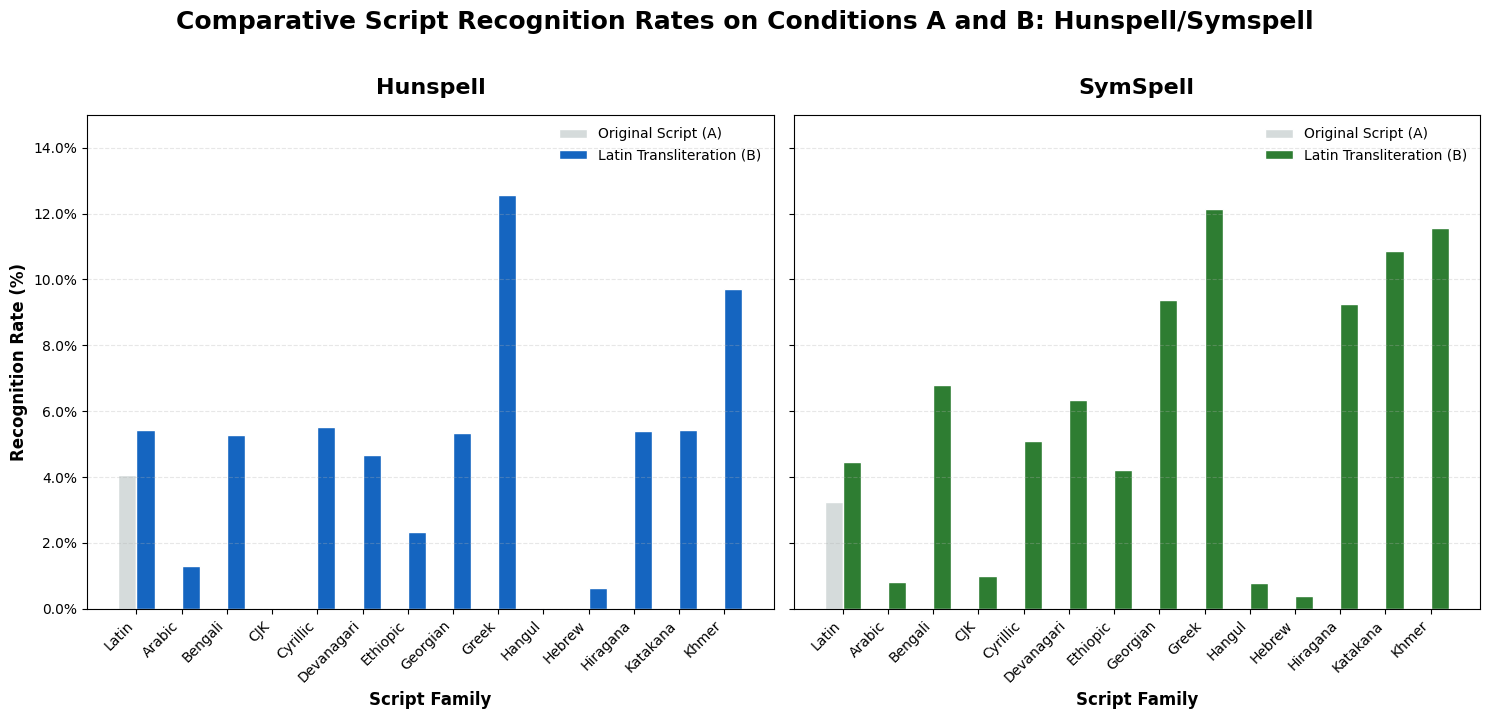

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick

# --- Configuration ---
scripts = ab_brk['script'].tolist()
x = np.arange(len(scripts))
w = 0.4
low_perf_tools = ['Hunspell', 'SymSpell']

# Create 2-panel figure
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

for i, tool in enumerate(low_perf_tools):
    ax = axes[i]
    vals_a = ab_brk[f'{tool}_A'].values
    vals_b = ab_brk[f'{tool}_B'].values
    color_b = TOOL_COLORS_B[tool]

    ax.bar(x - w/2, vals_a, width=w, label='Original Script (A)', color='#D5DBDB', edgecolor='white')
    ax.bar(x + w/2, vals_b, width=w, label='Latin Transliteration (B)', color=color_b, edgecolor='white')

    # Precision Scaling
    ax.set_ylim(0, 15)
    ax.set_title(tool, fontsize=16, fontweight='bold', pad=15)
    
    # Labeling
    ax.set_xticks(x)
    ax.set_xticklabels(scripts, rotation=45, ha='right', fontsize=10)
    ax.set_xlabel('Script Family', fontsize=12, fontweight='bold')
    
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    
    if i == 0:
        ax.set_ylabel('Recognition Rate (%)', fontsize=12, fontweight='bold')
    
    ax.legend(loc='upper right', frameon=False, fontsize=10)

fig.suptitle('Comparative Script Recognition Rates on Conditions A and B: Hunspell/Symspell', 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('hunspell_symspell_recognition.png', dpi=300, bbox_inches='tight')
plt.show()

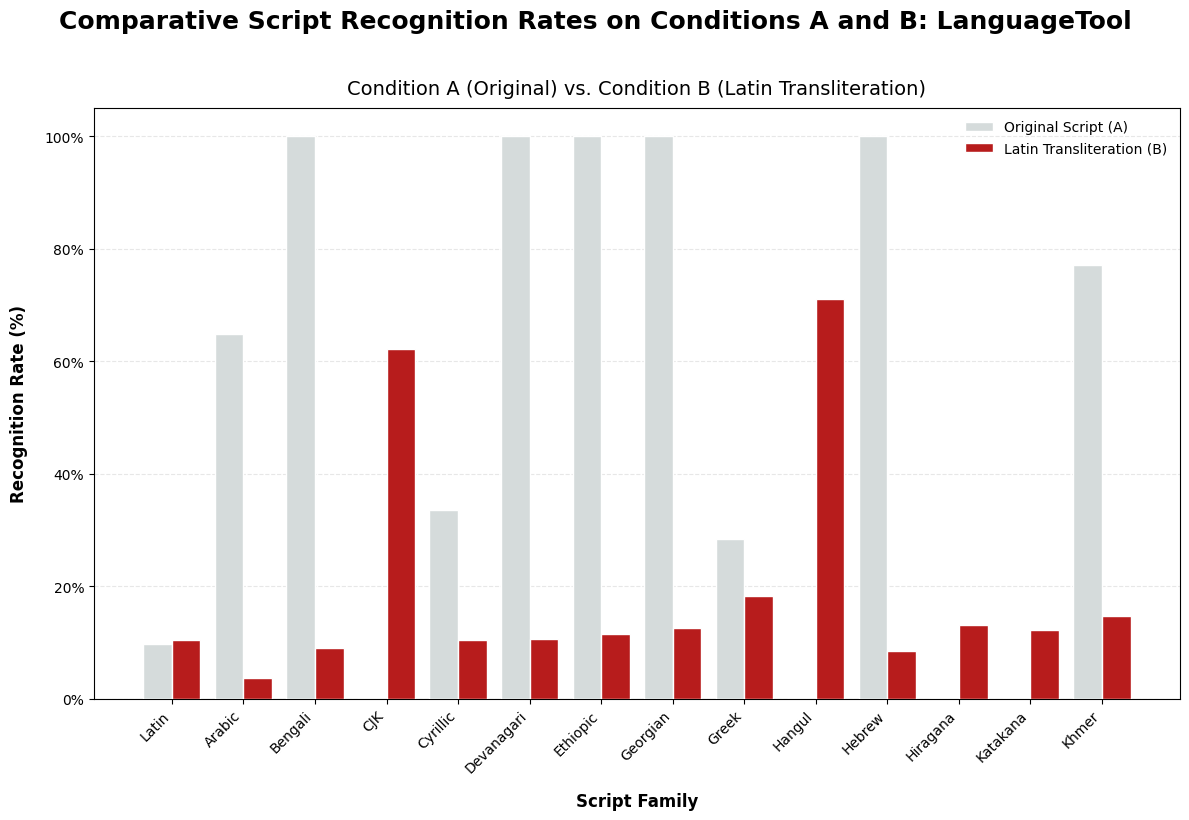

In [45]:
# --- Standalone LanguageTool Plot ---

# 1. Define the tool to match your ab_brk column names
tool = 'LanguageTool'

# 2. Get the X-axis labels and positions from ab_brk
scripts = ab_brk['script'].tolist()
x = np.arange(len(scripts))
w = 0.4

fig, ax = plt.subplots(figsize=(12, 8))

# 3. Reference ab_brk directly for precision
vals_a = ab_brk[f'{tool}_A'].values
vals_b = ab_brk[f'{tool}_B'].values

color_b = '#b71c1c'  # LT Red
color_a = '#D5DBDB'  # Condition A (gray)

ax.bar(x - w/2, vals_a, width=w, label='Original Script (A)', 
       color=color_a, edgecolor='white', zorder=3)

ax.bar(x + w/2, vals_b, width=w, label='Latin Transliteration (B)', 
       color=color_b, edgecolor='white', zorder=3)

# --- Styling & Precision ---
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(scripts, rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Script Family', fontsize=12, fontweight='bold', labelpad=12)
ax.set_ylabel('Recognition Rate (%)', fontsize=12, fontweight='bold', labelpad=12)

fig.suptitle('Comparative Script Recognition Rates on Conditions A and B: LanguageTool', 
             fontsize=18, fontweight='bold', y=1.02)
ax.set_title('Condition A (Original) vs. Condition B (Latin Transliteration)', fontsize=14, pad=10)

ax.legend(loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('languagetool_recognition.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
# ── Comparison Analysis: Greek Transliterations vs. Latin Dataset ────────────

# 1. Create a reference set of names that are natively Latin script
# Using a set for O(1) lookup speed
latin_names_set = set(df[df['name_script'] == 'Latin']['name'].unique())

# 2. Filter for Greek names
df_greek = df[df['name_script'] == 'Greek'].copy()

# 3. Check if the transliterated version (name_latin) exists in the Latin set
df_greek['is_in_latin_dataset'] = df_greek['name_latin'].isin(latin_names_set)

# 4. Calculate results
total_greek = len(df_greek)
matches = df_greek['is_in_latin_dataset'].sum()
match_rate = (matches / total_greek) * 100

print(f"Total Greek names analyzed: {total_greek:,}")
print(f"Greek transliterations found in Latin dataset: {matches:,}")
print(f"Overlap Rate: {match_rate:.2f}%")

# Optional: View a few examples of matches
if matches > 0:
    print("\nExample matches (Greek Original -> Latin Match):")
    print(df_greek[df_greek['is_in_latin_dataset']][['name', 'name_latin']].head(10).to_string(index=False))

Total Greek names analyzed: 3,243
Greek transliterations found in Latin dataset: 2,585
Overlap Rate: 79.71%

Example matches (Greek Original -> Latin Match):
    name name_latin
     Άβα        Ava
  Άγγελα     Aggela
 Άγγελος    Aggelos
    Άγης       Agis
  Άδωνης     Adonis
    Άθως      Athos
    Άκης       Akis
    Άλεξ       Alex
   Άλκης      Alkis
Άλκηστις   Alkistis
